In [7]:
# DATA PREPARATION

import pandas as pd

df = pd.read_csv("Diabetes_Health_Indicators_Dataset_5050Split.csv")

cols_to_convert = [
    "Diabetes_binary", "HighBP", "HighChol", "Smoker", "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump", "Stroke", "HeartDiseaseorAttack", "GenHlth", "DiffWalk", "Sex", "CholCheck", "AnyHealthcare", "NoDocbcCost"
]
df[cols_to_convert] = df[cols_to_convert].astype("int8")

cols_to_convert_2 = [
    "BMI", "MentHlth", "PhysHlth", "Age", "Education", "Income"
]
df[cols_to_convert_2] = df[cols_to_convert_2].astype("int64")
print("\n", df.columns)
print("\nNumber of Rows and Columns:", df.shape)


 Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

Number of Rows and Columns: (70692, 22)


Correlation Matrix: Lifestyle Cols vs Diabetes_binary:
Smoker               0.09
Fruits              -0.05
Veggies             -0.08
HvyAlcoholConsump   -0.09
PhysActivity        -0.16
Name: Diabetes_binary, dtype: float64


Text(0.5, 1.0, 'CORRELATION HEATMAP: LIFESTYLE VS RISK OF DIABETES')

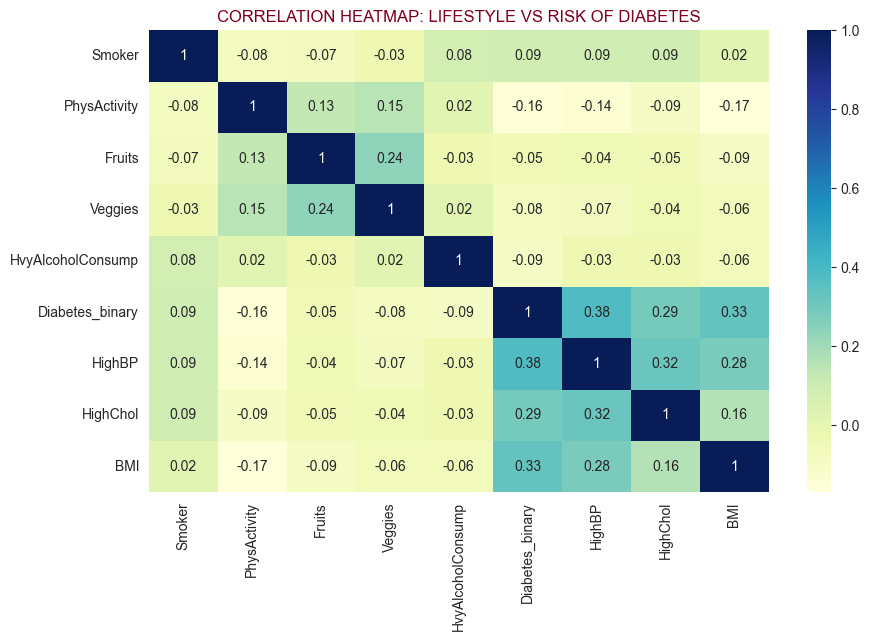

In [8]:
# CORRELATION ANALYSIS BETWEEN LIFESTYLE VS RISK OF DIABETES

import matplotlib.pyplot as plt
import seaborn as sns

habit_cols = [
    'Smoker',
    'PhysActivity',
    'Fruits',
    'Veggies',
    'HvyAlcoholConsump'
]
risk_cols = [
    'Diabetes_binary', # Target
    'HighBP',
    'HighChol',
    'BMI'
]
cols_for_corr = habit_cols + risk_cols
# method="spearman" is used for not being influenced by outliers and complicated data types
corr_matrix = df[cols_for_corr].corr(method="spearman").round(2)
print("Correlation Matrix: Lifestyle Cols vs Diabetes_binary:")
print(
    corr_matrix['Diabetes_binary'][habit_cols].sort_values(ascending=False)
)

# Visualization
plt.figure(figsize = (10,6))
sns.heatmap(
    corr_matrix,
    annot=True, # her hücrenin içine rakam olarak korelasyon değerini yazar
    cmap="YlGnBu"
)
plt.title("CORRELATION HEATMAP: LIFESTYLE VS RISK OF DIABETES", color="#800020")


Finding the best parametres with GridSearchCV...
The best parametres: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
The best Cross-Validation score (Average in the training set): %74.75
              precision    recall  f1-score   support

           0       0.76      0.73      0.74      7090
           1       0.74      0.77      0.75      7049

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



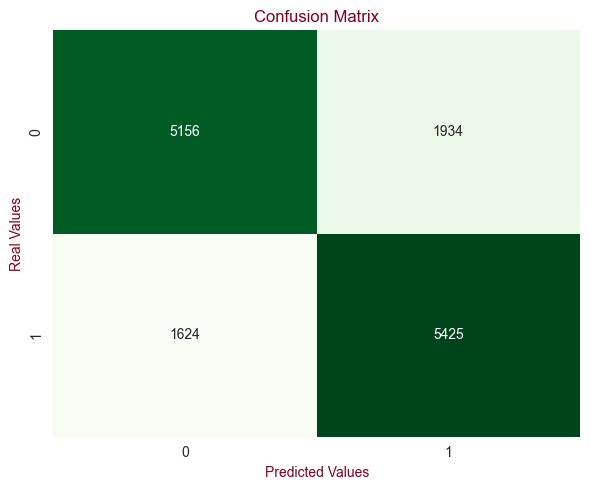

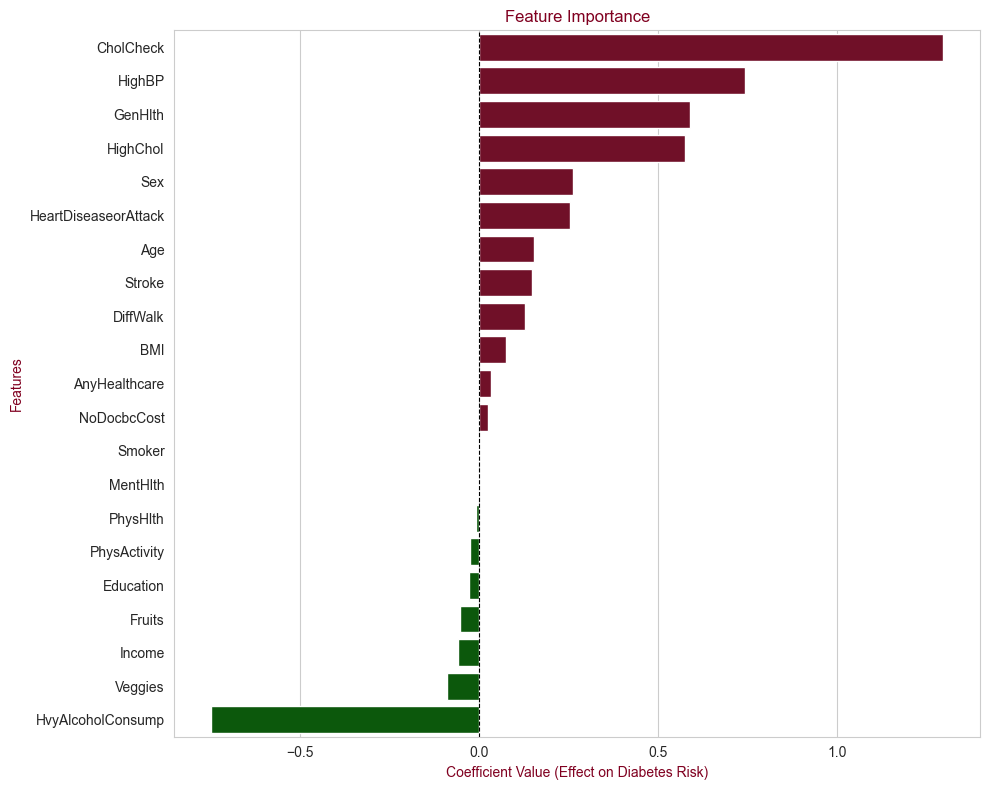

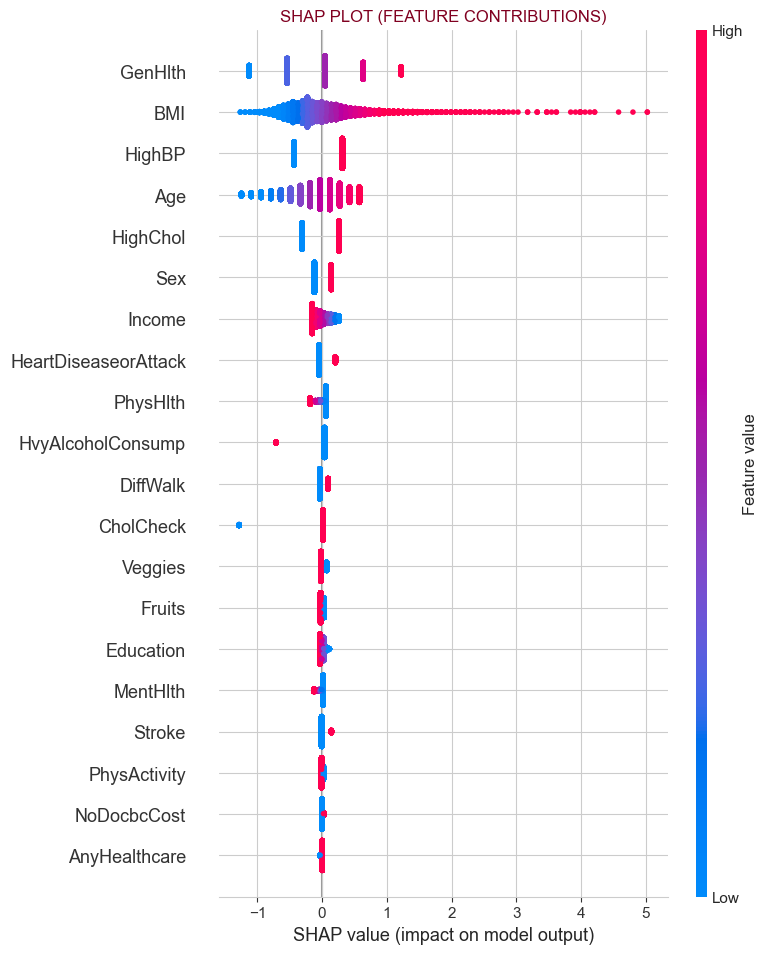

In [9]:
# LOGISTIC REGRESSION (CLASSIFICATION ALGORYTHM) TO PREDICT DIABETES (YES OR NO)

import shap
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')

# Target
y = df["Diabetes_binary"]
# Independent Variables
X = df.drop("Diabetes_binary", axis=1) # axis=1 -> Sütun başlıklarını tarayıp, 'Diabetes_binary' ismini bulup düşürecek / axis=0 olsa satırda

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identifying GridSearch Parameters (modelin karakterini değiştirir (modeli daha esnek, daha katı yapar))
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear'], # 'liblinear' küçük/orta veri setleri için iyidir ve l1/l2 destekler
    'penalty': ['l1', 'l2']  # l1 gereksiz feature'leri eler, l2 feature'lerde az da olsa katkı varsa sıfırlamaz küçültür
}

# Defining Model
log_reg = LogisticRegression(
    max_iter=1000
    # 1000 to Guarantee the Model / modele verilen maksimum adım sayısıdır, 350 de biterse durur sonuç değişmez
)

# Building Grid Search Model (w/ k-fold)
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5, # Veriyi 5 parçaya böler 4'ü ile eğitip 1'i ile test eder (bunu 5 kez tekrarlar) / 5 makine öğrenmesinde çok yaygın bir standarttır
    scoring='accuracy',
    n_jobs=-1 # İşlemcinin tüm çekirdeklerini kullanır
)

print("\nFinding the best parametres with GridSearchCV...")
grid_search.fit(X_train, y_train)
print(f"The best parametres: {grid_search.best_params_}")
print(f"The best Cross-Validation score (Average in the training set): %{grid_search.best_score_*100:.2f}")

# Selecting Best Model with Best Score
best_model = grid_search.best_estimator_ # tek bir model gibi gözükse de arka planda 8 farklı model çalışıyor / yüksek puanlı seçilir
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False
)
plt.title('Confusion Matrix', color="#800020")
plt.ylabel('Real Values', color="#800020")
plt.xlabel('Predicted Values', color="#800020")
plt.tight_layout()
plt.show()

# Feature Importance
coefficients = best_model.coef_[0] # En iyi modelden katsayılar (Coefficients) çekilyor
features = X.columns
feature_imp = pd.DataFrame(
    {
        'Feature': features,
        'Coefficient': coefficients
    }
)
feature_imp = feature_imp.sort_values(by='Coefficient', ascending=False)
plt.figure(figsize=(10, 8))
colors = ['#800020' if c > 0 else '#006400' for c in feature_imp['Coefficient']]
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=feature_imp,
    palette=colors,
    hue='Feature',
    legend=False
)
plt.title('Feature Importance', color="#800020")
plt.xlabel('Coefficient Value (Effect on Diabetes Risk)', color="#800020")
plt.ylabel('Features', color="#800020")
plt.axvline(
    x=0,
    color='black',
    linestyle='--',
    linewidth=0.8
) # 0 noktasına referans çizgisi
plt.tight_layout()
plt.show()

# SHAP Graph (Matplotlib'in içinde yer almaz bağımsız Python kütüphanesidir)
# Hesapladığı değerleri grafiğe dökmek için arka planda Matplotlib'i kullanır
explainer = shap.LinearExplainer(best_model, X_train) # Modelin bir şeyi "yüksek" / "düşük" demesi için "normal"in (X_train) ne olduğunu bilmesi gerek
shap_values = explainer.shap_values(X_test) # X_test üzerinden SHAP değerlerini hesaplama
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns,
    show=False # Matplotlib'e müdahele edebilmek için False
)
plt.title("SHAP PLOT (FEATURE CONTRIBUTIONS)", color="#800020")
plt.show()

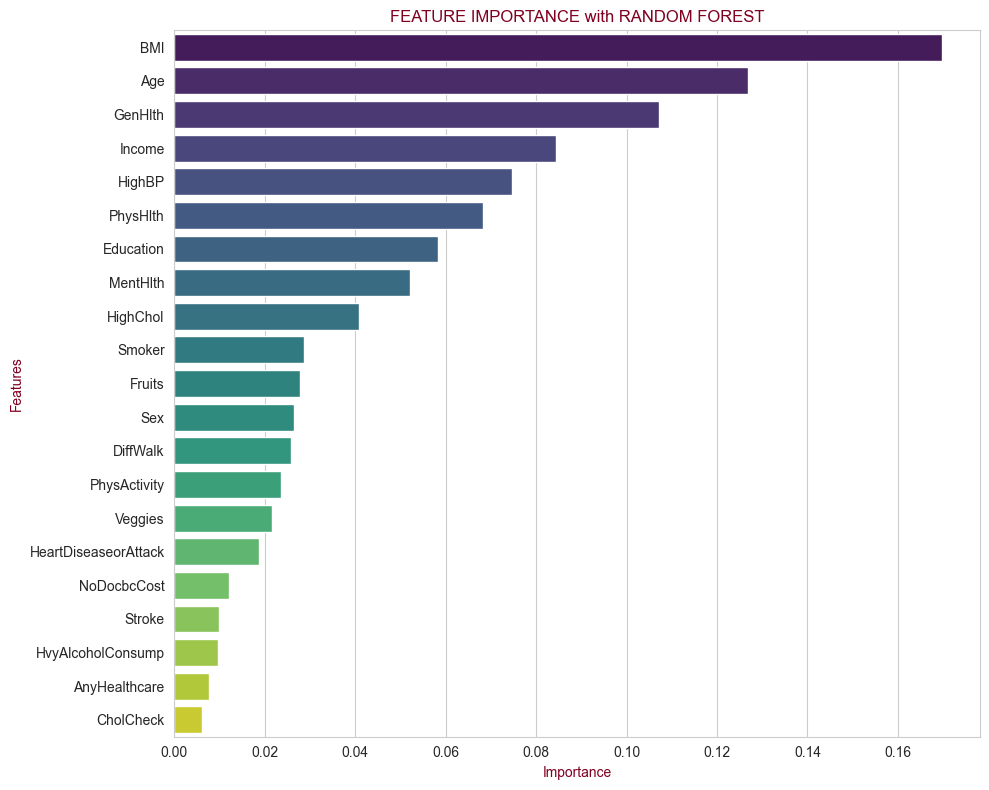

In [10]:
# LEARNING VARIABLE IMPORTANCE with RANDOM FOREST CLASSIFIER

# Random Forest algoritması, model kurulurken hangi değişkenin (sütunun) tahminde ne kadar etkili olduğunu otomatik olarak hesaplar. Aamacımız modelin "öğrenirken" çıkardığı notlara (Feature Importance) bakıyoruz.
from sklearn.ensemble import RandomForestClassifier

X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

# Taking Feature Importance Values
importances = rf_model.feature_importances_
feature_names = X.columns

# Creating DataFrame and Listing
listing = pd.DataFrame(
    {
        'Feature': feature_names,
        'Importance': importances
    }
).sort_values(by="Importance", ascending=False) # Büyükten küçüğe sıralama / True olursa küçükten büyüğe

plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=listing,
    palette='viridis',
    hue='Feature',
    legend=False
)
plt.title("FEATURE IMPORTANCE with RANDOM FOREST", color="#800020")
plt.xlabel("Importance", color="#800020")
plt.ylabel("Features", color="#800020")
plt.tight_layout()
plt.show()

Real Value of Patient: 1 (0:No Diabet, 1:Yes Diabet)


<Figure size 1200x600 with 0 Axes>

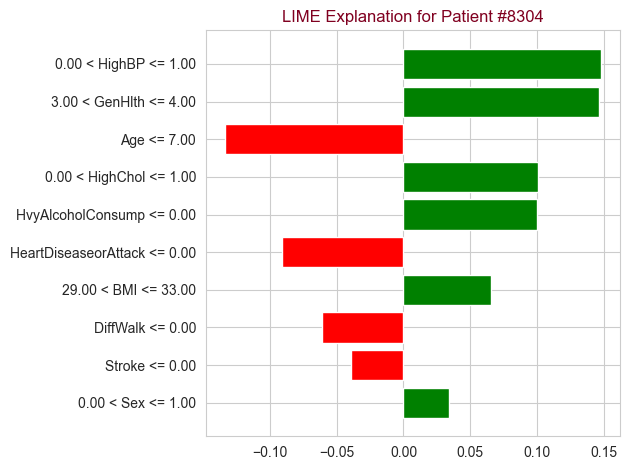

[('0.00 < HighBP <= 1.00', 0.15), ('3.00 < GenHlth <= 4.00', 0.15), ('Age <= 7.00', -0.13), ('0.00 < HighChol <= 1.00', 0.1), ('HvyAlcoholConsump <= 0.00', 0.1), ('HeartDiseaseorAttack <= 0.00', -0.09), ('29.00 < BMI <= 33.00', 0.07), ('DiffWalk <= 0.00', -0.06), ('Stroke <= 0.00', -0.04), ('0.00 < Sex <= 1.00', 0.03)]


In [11]:
# ANALYZING ONE PATIENT WITH LIME USING RANDOM FOREST CLASSIFIER

import random
import warnings
import numpy as np
import lime.lime_tabular
warnings.filterwarnings("ignore", message="X does not have valid feature names")

X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

# Creating LIME Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values, # Numpy array olarak verilmeli / LIME'ın hastayı yorumlayabilmesi için normal olanı bilmesi gerek
    feature_names=X.columns, # Sütun isimlerini liste olarak verdik
    class_names=['No Diabetes', 'Diabetes'], # 0 ve 1 rakamlarının insan dilindeki karşılığı
    mode='classification' # Sınıflandırma problemi
)

# Selecting Random Diabetic Patient
diabetic_indices = np.where(y_test == 1)[0] # Only diabetic patients
patient_index = random.choice(diabetic_indices)
patient_data = X_test.iloc[ # .iloc = Pandas'ın sıra numarasına göre seçim yapma komutu
    # büyük test setinden, incelemek istediğimiz tek bir hastayı alarak patient_data değişkenine kaydeder
    patient_index
]
print(f"Real Value of Patient: {y_test.iloc[patient_index]} (0:No Diabet, 1:Yes Diabet)")

# Generating Explanation
exp = explainer.explain_instance(
    data_row=patient_data.values, # açıklmasını istediğin hastanın verileri / .values veriyi başlıklardan arındırır
    predict_fn=rf_model.predict_proba, # Tahmin için modelin beynini kullan. Ama bana sadece sonucu (0 veya 1) söyleme, Olasılıkları (Probability) söyle
    num_features=10 # En önemli 10 özelliği göster
)

# LIME Graph
plt.figure(figsize=(12, 6))
exp.as_pyplot_figure()
plt.title(f"LIME Explanation for Patient #{patient_index}", color="#800020")
plt.tight_layout()
plt.show()

# Showing Numerical List / ('0.00 < HighBP <= 1.00', 0.15) -> Tansiyonunun olması, diyabet risk puanını 0.15 artırmış
rounded_list = [(x[0], round(x[1], 2)) for x in exp.as_list()]
print(rounded_list)

Model: "Sequential_Predict_Diabetes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 18)             │           396 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            19 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 415 (1.62 KB)

 Trainable params: 415 (1.62 KB)

 Non-trainable params: 0 (0.00 B)


Training the Neural Network...
Epoch 1/20
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 1s 744us/step - accuracy: 0.7209 - loss: 0.5511 - val_accuracy: 0.7459 - val_loss: 0.5104
Epoch 2/20
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 1s 668us/step - accuracy: 0.7455 - loss: 0.5185 - val_accuracy: 0.7471 - val_loss: 0.5064
Epoch 3/20
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 1s 689us/step - accuracy: 0.7500 - loss: 0.5147 - val_accuracy: 0.7471 - val_loss: 0.5056
Epoch 4/20
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 1s 672us/step - accuracy: 0.7482 - loss: 0.5127 - val_accuracy: 0.7473 - val_loss: 0.5052
Epoch 5/20
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 1s 682us/step - accuracy: 0.7499 - loss: 0.5117 - val_accuracy: 0.7479 - val_loss: 0.5041
Epoch 6/20
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 1s 692us/step - accuracy: 0.7508 - loss: 0.5108 - val_accuracy: 0.7485 - val_loss: 0.5049
Epoch 7/20
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 1s 694us/step - accuracy: 0.7518 - loss: 0.5102 - val_accuracy: 0.7479 - val_loss: 0.5041
Epoch 8/20
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 2s

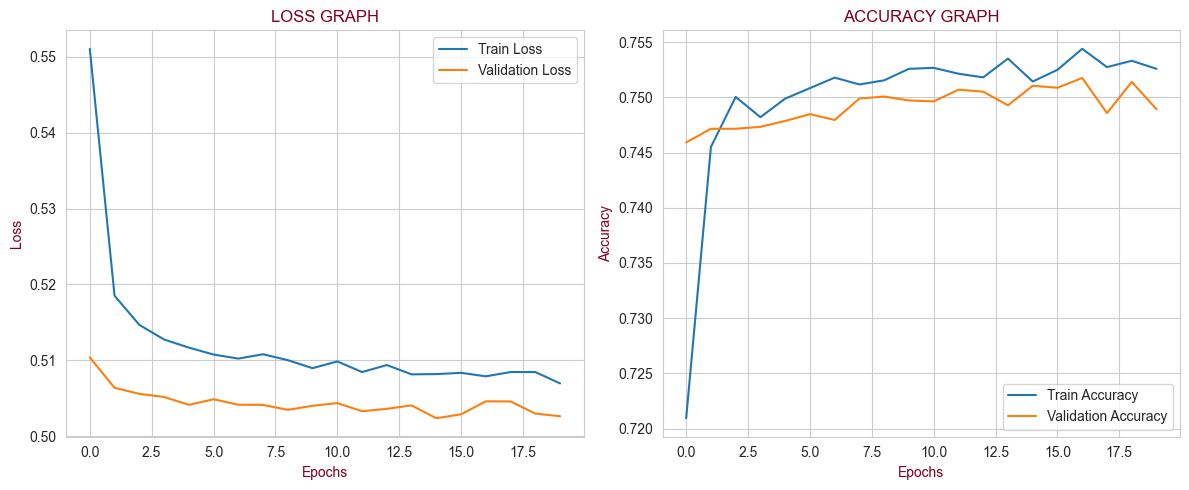

In [12]:
# WORKING on NEURAL NETWORK with to PREDICT DIABETES (Multi-Layer Perceptron Model)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")

X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler() # Standardization
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Sequential(name="Sequential_Predict_Diabetes") # Sıralıdır / Sinir ağını oluşturacak katmanları (layers) arka arkaya dizer
model.add( # Artificial Neuron layer: data is processed and learning takes place
    Dense(
        18, # Feature'ları 18 adet nörona (yapay beyin hücresine) dağıtır / Giriş sayısına yakın bir değer vermek iyidir
        activation='relu', # Negatifleri sıfırlar, sadece pozitifleri geçirir (modelin öğrenmesini hızlandırır)
        input_dim=X_train.shape[1] # Giriş Katmanı (Input Layer): 21 sütunun girdiği ilk kapı
    )
)
model.add(Dropout(0.2)) # prevent overfitting / Her eğitim adımında nöronlarının %20'sini rastgele kapatır
model.add( # Decision Mechanism: işlem sonunda tek nöron, işlenen veriyi alıp "Diyabet Var" "Yok" kararını veriyor
    Dense(
        1, # Önceki 16 nörondan gelen bilgiyi tek bir karara (1 nöron) indirger / kaç çeşit cevap bekleniyorsa o kadar nöron olmalı
        activation='sigmoid' # sonucu %0 ile %100 arasında olasılığa çevirir (%85 Diyabet)
    )
)
model.compile( # Modelin "nasıl öğreneceğini" belirler. Hata nasıl hesaplanacak (loss), hatalar nasıl düzeltilecek (optimizer)?
    optimizer='adam', # Adaptive Moment Estimation Optimizasyon modeli: Öğrenmeyi hızlandıran ve hataları minimize eden algoritma
    loss='binary_crossentropy', # Hata hesaplama yöntemi
    metrics=['accuracy']
)
model.summary() # çıktıda modelin mimarisini, katmanların boyutlarını ve öğrenilecek parametre sayısını özetler

# Training the Model
print("\nTraining the Neural Network...")
history = model.fit( # Training Period of Parameters: Modelin ne kadar süre çalışacağını belirler
    X_train_scaled, y_train,
    epochs=20, # model veri setini baştan sona 20 kere okuyacak / 20 deneme-yanılma ile bulunan başlangıç değerdir
    batch_size=32, # Her seferinde 32 hasta verisi işlenecek / 2'nin katları olmalı
    # 32 hızlı öğrenme, kararlı sonuçlar için kabul görmüş altın standart
    validation_split=0.2, # %80'lik Train verisinin içinden geçici %20 alma / (%20) endüstri standardır
    # Her epoch sonunda, bu %20'lik parça üzerinde kendini dener
    verbose=1 # modelin eğitim sırasında ekrana ne kadar yazı yazacağını belirler / 0: None, 1: Full, 2: Epochs Only
)

y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype("int32")
print("\n Classification Report of Neural Network")
print(classification_report(y_test, y_pred))

# Loss Graph
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(
    history.history['loss'],
    label='Train Loss'
)
plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)
plt.title('LOSS GRAPH', color="#800020")
plt.xlabel('Epochs', color="#800020")
plt.ylabel('Loss', color="#800020")
plt.legend()

# Accuracy Graph
plt.subplot(1, 2, 2)
plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)
plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)
plt.title('ACCURACY GRAPH', color="#800020")
plt.xlabel('Epochs', color="#800020")
plt.ylabel('Accuracy', color="#800020")
plt.legend()
plt.tight_layout()
plt.show()